In [4]:
import pandas as pd
import numpy as np
import os

# 1. Dates banate hain (1 saal ka daily data)
dates = pd.date_range(start='2024-01-01', periods=365, freq='D')

# 2. Random Temperature aur Humidity banate hain
np.random.seed(42) # Taaki aapka aur mera data ekdum same aaye
temperature = np.random.uniform(10, 45, size=365) # 10°C se 45°C tak [cite: 6]
humidity = np.random.uniform(30, 90, size=365)    # 30% se 90% tak [cite: 7]

# 3. Data ko ek Pandas Table (DataFrame) me dalte hain
df = pd.DataFrame({
    'date': dates,
    'temperature': temperature,
    'humidity': humidity
})

# 4. Feature Engineering: Pata lagate hain ki Weekend (Sat/Sun) hai ya nahi [cite: 9]
df['is_weekend'] = df['date'].dt.dayofweek.isin([5, 6]).astype(int)

# 5. Target Variable (Energy Consumption) calculate karte hain
# Logic: Garmi aur humidity zyada hogi toh AC zyada chalega (Energy badhegi)
# Weekend par offices band hote hain toh energy kam hogi
df['energy_consumption'] = 200 + (df['temperature'] * 5) + (df['humidity'] * 2) - (df['is_weekend'] * 50) + np.random.normal(0, 10, size=365)

# 6. Is data ko 'data' folder me CSV file banakar save karte hain
df.to_csv('../data/energy_data.csv', index=False)

print("Badhai Ho! Dataset ban gaya aur data folder me save ho gaya! 🎉")
df.head() # Shuru ki 5 lines dekhte hain

Badhai Ho! Dataset ban gaya aur data folder me save ho gaya! 🎉


,date,temperature,humidity,is_weekend,energy_consumption
0,2024-01-01,23.108904,53.166158,0,425.821359
1,2024-01-02,43.275001,87.671434,0,587.508026
2,2024-01-03,35.619788,84.321039,0,549.638765
3,2024-01-04,30.953047,41.747468,0,459.014179
4,2024-01-05,15.460652,34.161678,0,354.337865


In [1]:
# 1. Data me koi missing value (kachra) toh nahi hai?
print("--- Data Ka Structure ---")
df.info()

print("\n--- Data Ka Maths/Stats ---")
display(df.describe())

--- Data Ka Structure ---


NameError: name 'df' is not defined

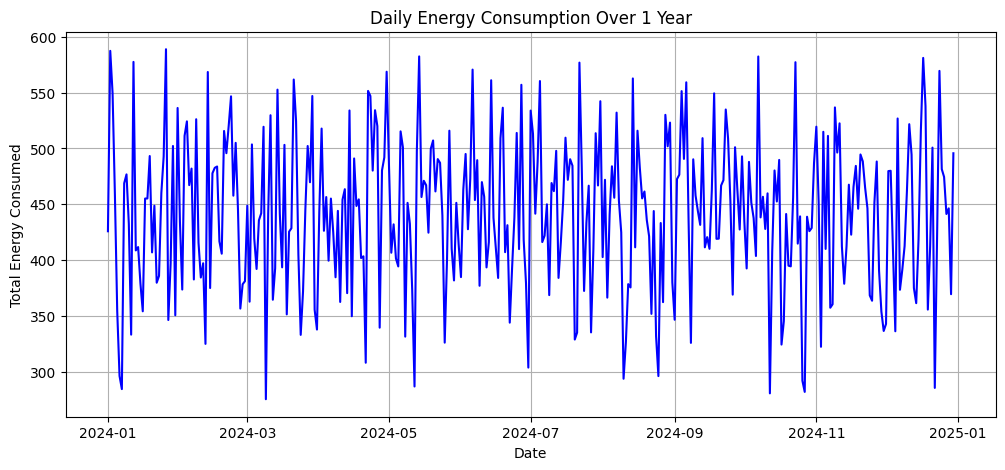

In [5]:
import matplotlib.pyplot as plt

# Graph ka size set kar rahe hain (lamba aur chauda)
plt.figure(figsize=(12, 5))

# Date aur Energy Consumption ko plot kar rahe hain
plt.plot(df['date'], df['energy_consumption'], color='blue', label='Energy Use')

# Graph ko sundar banane ke liye labels daal rahe hain
plt.title('Daily Energy Consumption Over 1 Year')
plt.xlabel('Date')
plt.ylabel('Total Energy Consumed')
plt.grid(True) # Piche lines banane ke liye
plt.show()